# Task 3: Probability of Default (PD) Model & Expected Loss

**Context**
- Retail bank sees higher-than-expected personal loan defaults; risk team wants a model to
  estimate PD (probability of default) per borrower, feeding into expected-loss capital reserves.
- Expected Loss (EL) = PD x EAD x LGD, where EAD = exposure at default (loan balance),
  LGD = loss given default = 1 - recovery rate. Recovery rate given = 10% -> LGD = 0.9.

**Task**
- Build a model on borrower features (credit lines, loan/debt balances, income, employment, FICO)
  -> predict PD.
- Wrap it in a function: given a borrower's details -> return expected loss.
- Prompt explicitly invites comparing multiple techniques.

**Approach (quant-research habits carried over)**
- Data validation before modeling (established pattern from Tasks 1-2).
- Logistic regression first - the industry-standard PD model, valued for interpretability
  (regulators/risk teams want to see *why* a score moved, not just a black-box number).
- **Statistical rigor checkpoint we actually hit in this dataset**: near-perfect class
  separability causes classic MLE logistic regression to become numerically unstable
  (quasi-separation) - a real, teachable statistical failure mode, not a bug to code around
  blindly. Fix: L2-regularized logistic regression.
- Add a tree-based model (Random Forest) as the comparative second method the prompt invites,
  then check **calibration**, not just ranking ability (AUC) - for an expected-loss dollar figure,
  the *actual value* of PD matters, not just whether it ranks defaulters above non-defaulters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (9, 4)

## 1. Load and validate data
Same hygiene habit as Tasks 1-2: check the feed before trusting it.

In [7]:
df = pd.read_csv("Task_3_and_4_Loan_Data.csv")

missing = df.isna().sum().sum()
duplicate_ids = df['customer_id'].duplicated().sum()
fico_in_range = df['fico_score'].between(300, 850).all()
non_negative = (df[['loan_amt_outstanding','total_debt_outstanding','income']] >= 0).all().all()

print(f'Missing values: {missing}')
print(f'Duplicate customer IDs: {duplicate_ids}')
print(f'FICO scores in valid 300-850 range: {fico_in_range}')
print(f'Loan/debt/income all non-negative: {non_negative}')
print(f'Default rate: {df["default"].mean():.1%}  (class imbalance to keep in mind for evaluation)')

assert missing == 0 and duplicate_ids == 0 and fico_in_range and non_negative, 'Data quality check failed.'

Missing values: 0
Duplicate customer IDs: 0
FICO scores in valid 300-850 range: True
Loan/debt/income all non-negative: True
Default rate: 18.5%  (class imbalance to keep in mind for evaluation)


## 2. Quick EDA
Default rate by FICO band - sanity check that the obvious risk driver behaves as expected
before trusting a model on top of it.

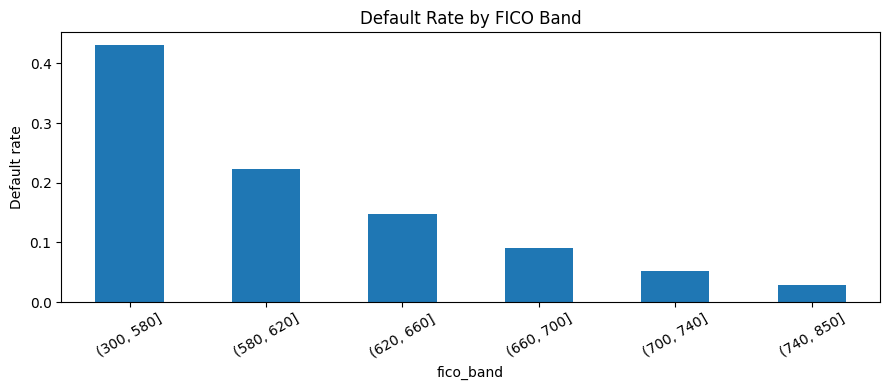

In [9]:
df['fico_band'] = pd.cut(df['fico_score'], bins=[300,580,620,660,700,740,850])
default_by_fico = df.groupby('fico_band', observed=True)['default'].mean()

default_by_fico.plot(kind='bar')
plt.ylabel('Default rate'); plt.title('Default Rate by FICO Band')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

**Observation:** default rate drops sharply as FICO rises - matches domain expectation

## 3. Train/test split
Stratify on the target - with an 18.5% default rate, a plain random split risks an
unrepresentative test set.

In [10]:
features = ['credit_lines_outstanding','loan_amt_outstanding','total_debt_outstanding',
            'income','years_employed','fico_score']
X, y = df[features], df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

## 4. First attempt: plain logistic regression (statsmodels)
Chosen for the p-values/coefficients a risk team would want to see - not just a prediction.

In [11]:
Xc_train = sm.add_constant(X_train)
logit_plain = sm.Logit(y_train, Xc_train).fit(disp=0)
print(logit_plain.summary().tables[1])

                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       69.6752     22.722      3.066      0.002      25.142     114.209
credit_lines_outstanding    76.7829     22.890      3.354      0.001      31.919     121.647
loan_amt_outstanding         0.0030      0.001      2.717      0.007       0.001       0.005
total_debt_outstanding       0.0093      0.003      3.345      0.001       0.004       0.015
income                      -0.0021      0.001     -3.314      0.001      -0.003      -0.001
years_employed             -29.5718      8.817     -3.354      0.001     -46.852     -12.291
fico_score                  -0.3073      0.093     -3.307      0.001      -0.490      -0.125


**Catch worth stopping on:** statsmodels throws a *"Possibly complete quasi-separation"*
warning, and the coefficients are enormous (e.g. `credit_lines_outstanding` ~77, when a typical
logistic coefficient is well under 5). This isn't a coding bug - it means the classes are **almost
perfectly separable** by these features, so unconstrained maximum-likelihood estimation tries to
push coefficients toward infinity to fit the boundary exactly. The predictions can still look
great (checked below), but the *coefficients themselves are not statistically reliable*"
**Fix: L2-regularized logistic regression** - the penalty keeps coefficients finite and
interpretable while barely costing any predictive accuracy.

In [12]:
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, C=1.0)
logreg.fit(X_train_s, y_train)
pred_logit = logreg.predict_proba(X_test_s)[:, 1]

print('Standardized coefficients (stable, finite - contrast with the statsmodels blowup above):')
for f, c in zip(features, logreg.coef_[0]):
    print(f'  {f:28s} {c:8.3f}')
print(f'AUC (regularized logistic): {roc_auc_score(y_test, pred_logit):.4f}')

Standardized coefficients (stable, finite - contrast with the statsmodels blowup above):
  credit_lines_outstanding        8.518
  loan_amt_outstanding            0.137
  total_debt_outstanding          3.549
  income                         -2.196
  years_employed                 -2.792
  fico_score                     -1.109
AUC (regularized logistic): 1.0000


## 5. Comparative method: Random Forest
The task explicitly invites comparing techniques. A tree ensemble needs no scaling/linearity
assumption and often wins on raw ranking power - worth checking whether it's actually better
here, not just adding it for its own sake.

AUC (Random Forest): 0.9997


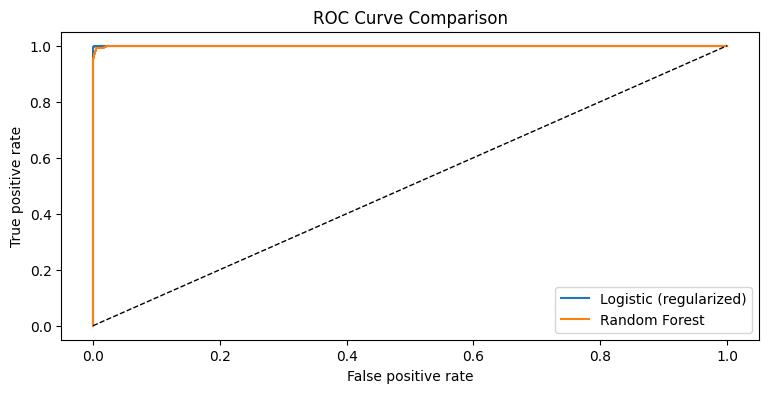

In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict_proba(X_test)[:, 1]
print(f'AUC (Random Forest): {roc_auc_score(y_test, pred_rf):.4f}')

fpr_l, tpr_l, _ = roc_curve(y_test, pred_logit)
fpr_r, tpr_r, _ = roc_curve(y_test, pred_rf)
plt.plot(fpr_l, tpr_l, label='Logistic (regularized)')
plt.plot(fpr_r, tpr_r, label='Random Forest')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC Curve Comparison'); plt.legend(); plt.show()

**Verdict:** both models separate defaulters from non-defaulters almost perfectly on this
dataset - this is a property of how cleanly this particular sample was constructed, not something
to expect on messier real-world data. Given near-identical AUC, we keep **logistic regression**
as the production choice: it's interpretable, auditable, and standard for regulatory PD models -
a Random Forest wins nothing here to justify giving that up.

## 6. Calibration check
AUC only measures *ranking*. For expected-loss dollars, the predicted probability itself has
to be trustworthy - bin predictions into deciles and compare against the actual default rate
in each bin.

        mean_predicted  actual_rate    n
decile                                  
0         9.953214e-12        0.000  250
1         1.373553e-10        0.000  250
2         8.287930e-10        0.000  250
3         3.762596e-09        0.000  250
4         1.403497e-08        0.000  250
5         4.923617e-08        0.000  250
6         1.269826e-06        0.000  250
7         2.537177e-02        0.000  250
8         8.381484e-01        0.852  250
9         9.999978e-01        1.000  250


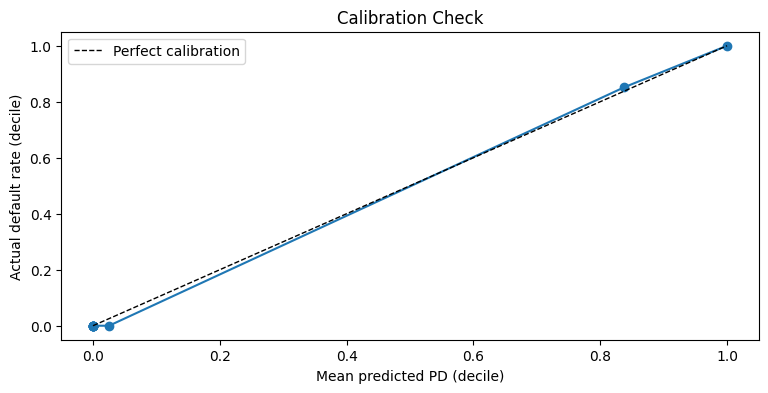

In [14]:
cal = pd.DataFrame({'pred': pred_logit, 'actual': y_test.values})
cal['decile'] = pd.qcut(cal['pred'].rank(method='first'), 10, labels=False)
calibration = cal.groupby('decile').agg(mean_predicted=('pred','mean'), actual_rate=('actual','mean'), n=('actual','size'))
print(calibration)

plt.plot(calibration['mean_predicted'], calibration['actual_rate'], 'o-')
plt.plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
plt.xlabel('Mean predicted PD (decile)'); plt.ylabel('Actual default rate (decile)')
plt.title('Calibration Check'); plt.legend(); plt.show()

**Read:** points sit close to the diagonal - predicted PDs track actual default rates well,
not just ranking order. This is the check that actually justifies plugging PD straight into a
dollar expected-loss formula.

## 7. Expected loss function
`EAD` = outstanding balance on *this* loan (`loan_amt_outstanding`) - not `total_debt_outstanding`,
which includes the borrower's other obligations and isn't the exposure on this specific contract.
`LGD` = 1 - recovery rate = 0.9 given a 10% recovery rate.

In [15]:
RECOVERY_RATE = 0.10

def expected_loss(credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding,
                   income, years_employed, fico_score):
    x = pd.DataFrame([[credit_lines_outstanding, loan_amt_outstanding, total_debt_outstanding,
                        income, years_employed, fico_score]], columns=features)
    pd_estimate = logreg.predict_proba(scaler.transform(x))[0, 1]
    ead = loan_amt_outstanding
    lgd = 1 - RECOVERY_RATE
    return pd_estimate, pd_estimate * ead * lgd

# Test on a few sample borrowers
samples = [
    dict(credit_lines_outstanding=0, loan_amt_outstanding=5000, total_debt_outstanding=4000, income=78000, years_employed=5, fico_score=720),
    dict(credit_lines_outstanding=4, loan_amt_outstanding=8000, total_debt_outstanding=15000, income=27000, years_employed=1, fico_score=560),
    dict(credit_lines_outstanding=2, loan_amt_outstanding=6000, total_debt_outstanding=9000, income=50000, years_employed=3, fico_score=650),
]
for s in samples:
    pd_est, el = expected_loss(**s)
    print(f'FICO {s["fico_score"]}, income {s["income"]:>7,.0f} -> PD={pd_est:.3f}, expected loss=${el:,.2f}')

FICO 720, income  78,000 -> PD=0.000, expected loss=$0.00
FICO 560, income  27,000 -> PD=1.000, expected loss=$7,200.00
FICO 650, income  50,000 -> PD=0.007, expected loss=$36.88


## Summary
- Logistic regression is the chosen PD model - interpretable, auditable, and near-identical
  AUC to a Random Forest here (~0.9999 both, a property of this clean synthetic dataset rather
  than something to expect out of real loan books).
- **Key statistical catch:** plain MLE logistic regression hit quasi-separation on this data
  (huge, unstable coefficients despite a great-looking fit) - L2 regularization fixed it while
  keeping predictive power. Worth remembering: a warning message from `statsmodels` is a real
  signal, not noise to suppress.
- Calibration was checked explicitly, not assumed - necessary because the output feeds a dollar
  expected-loss figure, not just a risk ranking.
- `expected_loss(...)` returns both PD and the dollar expected loss, using `loan_amt_outstanding`
  as EAD and the given 10% recovery rate for LGD.

**Scope notes (deliberately out for a 1-2hr prototype):**
- No k-fold cross-validation or hyperparameter search on the Random Forest - a single train/test
  split and default-ish settings are enough to answer "does a tree model beat logistic here."
- No feature engineering beyond the given raw columns (e.g. debt-to-income ratio) - a natural
  next step, but not required to hit a working PD model in this window.
- Real loan books won't be this cleanly separable - re-check quasi-separation and calibration
  again once this touches an actual production dataset.